**Training Your Model in PyTorch**

**Dataset and DataLoader**

`Dataset` is responsible for accessing and processing single instances of data.

The `DataLoader` pulls instances of data from the `Dataset` collects them in batches, and returns for consumption in trianing loop. `DataLoader` works with all kinds of data sets regardless of data. 

Use Fashion-MNIST dataset in TorchVision. use `torchvision.transforms.Normalize()` to zero-center and normalize distribution of image tile

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True, num_workers=2)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

print('Training set has {} instances.'.format(len(training_set)))
print('Validation set has {} instances.'.format(len(validation_set)))



100.0%
100.0%
100.0%
100.0%


Training set has 60000 instances.
Validation set has 10000 instances.


Shirt  Coat Sneaker Ankle boot


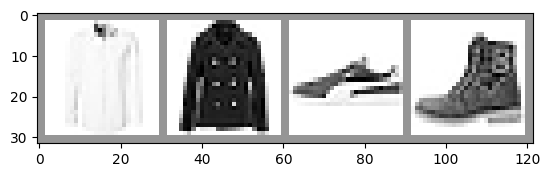

In [3]:
import matplotlib.pyplot as plt
import numpy as np
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

img_grid=torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

**The Model**

Variant of LeNet-5

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class GarmentCClassifier(nn.Module):
    def __init__(self):
        super(GarmentCClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
model=GarmentCClassifier()

**Loss Function**

For this example, we'll be using a cross-entropy loss. For demonstration purposes, create batches of dummy output and label values, run them through loss function, examine result.

In [5]:
loss_fn = torch.nn.CrossEntropyLoss()

dummy_output=torch.rand(4, 10)

dummy_labels=torch.tensor([1, 5, 3, 7])

print(dummy_output)
print(dummy_labels)

loss=loss_fn(dummy_output, dummy_labels)

print('Total loss for this batch: {}'.format(loss.item()))

tensor([[0.6754, 0.7737, 0.5464, 0.7449, 0.2033, 0.4487, 0.2372, 0.4100, 0.5056,
         0.7474],
        [0.9564, 0.0301, 0.6219, 0.6639, 0.2946, 0.7366, 0.0553, 0.5071, 0.8331,
         0.1207],
        [0.6150, 0.9560, 0.0038, 0.4410, 0.6159, 0.0377, 0.1854, 0.9853, 0.0545,
         0.1268],
        [0.3371, 0.7246, 0.9246, 0.6055, 0.0575, 0.7278, 0.6604, 0.3874, 0.8535,
         0.2645]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.2519493103027344


**Optimizer**

Instructuive try variations:
- learning rate determines size of the steps and optimizer takes. what does diff learning rate do to your training results in terms of accuracy
- momentum nudges optimizer in direction of strongest gradient
- try some different optimization algorithms

In [6]:
optimizer=torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

**The Training Loop**

Below we have a funcion that performs one training epoch. It enumerates data from DataLoader, and each pass on loop does:
- Gets a batch of training data from DataLoader
- Zeros the optimizer's gradients
- Performs an inference - that is, gets predictions from the model for an input batch
- calculates the loss for that set of predictions vs labels on dataset
- calculates backward gradients over the learning weights
- tells the optimizer to perform one learning step, that is adjust the model's learning weights based on observed gradients for this batch
- reports on loss every 100 batches
- reports the average per batch loss last 1000 batches for comparison with validation run

In [9]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(training_loader):
        inputs, labels = data

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.
    return last_loss

**Pre-Epoch Activity**

There are a couple things we'll want to do once per epoch:
- perform validation by checking our relative loss on a set of data that was not used for training
- save a copy of the model

In [11]:
timestamp=datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
writer=SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number=0

In [12]:
EPOCHS = 1

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)

    running_vloss = 0.0
    for i, vdata in enumerate(validation_loader):
        vinputs, vlabels = vdata
        voutputs = model(vinputs)
        vloss = loss_fn(voutputs, vlabels)
        running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    writer.add_scalars('Training vs. Validation Loss',
                       {'Training': avg_loss, 'Validation': avg_vloss}, epoch_number + 1)
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)
    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 2.0203817677795888
  batch 2000 loss: 0.9272900800555944
  batch 3000 loss: 0.7209440969079733
  batch 4000 loss: 0.6729987302031368
  batch 5000 loss: 0.6352592014018447
  batch 6000 loss: 0.5761535742431879
  batch 7000 loss: 0.5480513885344844
  batch 8000 loss: 0.5151082623963011
  batch 9000 loss: 0.5148177116271109
  batch 10000 loss: 0.4556789163619978
  batch 11000 loss: 0.43814753231796205
  batch 12000 loss: 0.4489252288412536
  batch 13000 loss: 0.4442143741507316
  batch 14000 loss: 0.41850340421218424
  batch 15000 loss: 0.4010938528049737
LOSS train 0.4010938528049737 valid 0.4258183538913727
